## Propensity Score Matching                                                                                                                                                                 
                                                                                                                                                                                            
Replicates the first-stage matching procedure from Mamkhezri, Sun & Yang (2026).                                                                                                             
                                                                                                                                                                                            
**Approach:**                                                                                                                                                                                
1. Restrict sample to census tracts that have at least one LMP pricing node (tracts without observable electricity prices cannot be used in DiD)
2. Define treatment: census tract has at least one data center with first entry between 2017–2025 (excludes always-treated and not-yet-treated units)                                        
3. Exclude tracts that ever had a data center (any year) from the control pool                                                                                                               
4. Estimate propensity scores via probit model using pre-treatment ACS demographics                                                                                                          
5. Exclude treated tracts outside common support                                                                                                                                             
6. Match each treated tract to its 10 nearest untreated neighbors (10-NN with replacement)                                                                                                   
7. Check covariate balance before and after matching                                                                                                                                         
                
**Covariates:**                                                                                                                                                    
- Population    
- % White residents                                                                                                                                                                          
- % High school graduates
- Median household income                                                                                                                                                                    
- Number of housing units
                                                                                                                                                                                            
**Output:** `va_matched_tracts.csv` — 52 rows (8 treated, 44 control) with propensity scores and group assignment                                                                            



In [22]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
warnings.filterwarnings('ignore')

DATA_DIR = next(
    p / "data" for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data").exists()
)

lmp_processed_dir = DATA_DIR / "processed" / "preprocessing" / "lmp_data"
analysis_dir = DATA_DIR / "processed" / "for_analysis"
matching_dir = DATA_DIR / "processed" / "preprocessing" / "pre_analysis"

In [23]:
# Load ACS demographic data
acs = pd.read_csv(matching_dir / "va_acs_2016_tract.csv", dtype={"GEOID": str})
print("ACS shape:", acs.shape)

# Load data center file
dc = pd.read_excel(analysis_dir / "datacenters_matched_tracts.xlsx",
                   dtype={"census_tract_geoid": str})
print("Data centers shape:", dc.shape)
print("\nData center columns:", dc.columns.tolist())

ACS shape: (1866, 10)
Data centers shape: (292, 43)

Data center columns: ['id', 'state_im3', 'state_abb', 'state_id', 'county', 'county_id', 'operator', 'ref', 'name', 'sqft', 'lon', 'lat', 'type', 'im3_id', 'fractracker_facility_name', 'fractracker_address', 'fractracker_city', 'zip', 'fractracker_county', 'fractracker_lat', 'fractracker_lon', 'fractracker_status', 'fractracker_location_confidence', 'fractracker_operator_name', 'fractracker_mw', 'sizerank', 'facility_size_sqft', 'property_size_acres', 'other_info', 'information_source', 'fractracker_id', 'match_distance_m', 'matched_flag', 'match_quality', 'name_similarity', 'source_year_found', 'year_basis_used', 'year_source_link', 'census_tract_geoid', 'census_tract_name', 'census_statefp', 'census_countyfp', 'census_tractce']


In [24]:
# Restrict ACS to only tracts that have at least one LMP pricing node
# Tracts without pnodes have no observable electricity prices and cannot be used in DiD
lmp = pd.read_csv(lmp_processed_dir / "va_lmp_yearly_avg_load_geo.csv", dtype={"census_geoid": str})
tracts_with_lmp = set(lmp["census_geoid"].dropna().unique())

acs = acs[acs["GEOID"].isin(tracts_with_lmp)].copy()
print(f"ACS tracts after restricting to tracts with LMP data: {len(acs)}")
print(f"  (dropped {1868 - len(acs)} tracts with no pricing nodes)")

ACS tracts after restricting to tracts with LMP data: 350
  (dropped 1518 tracts with no pricing nodes)


In [ ]:
# Tracts with LMP data but no ACS data — these are dropped from the analysis, check them
lmp_geoids = set(lmp["census_geoid"].unique())
acs_geoids = set(acs["GEOID"].unique())
missing_from_acs = lmp_geoids - acs_geoids

print(f"Tracts with LMP data but no ACS data (dropped): {len(missing_from_acs)}")
dropped = lmp[lmp["census_geoid"].isin(missing_from_acs)][["census_geoid", "census_name"]].drop_duplicates()
print(dropped.to_string())

Tracts with LMP data but no ACS data (dropped): 5
    census_geoid  census_name
216  51135980100       9801.0
416  51059980300       9803.0
429  51059980200       9802.0
511  51013980100       9801.0
664  51670980100       9801.0


These counties all have population = 0 (checked by manually confirming on census website). Therefore they have no ACS data that can be used for matching. 

In [27]:
# Compute first data center entry year per tract                                                                                                                                       
first_entry = (                                                                                                                                                                        
    dc.dropna(subset=["census_tract_geoid", "source_year_found"])                                                                                                                          
    .groupby("census_tract_geoid")["source_year_found"]                                                                                                                                    
    .min()      
    .reset_index()                                                                                                                                                                     
    .rename(columns={"census_tract_geoid": "census_geoid", "source_year_found": "first_entry_year"})
)                                                                                                                                                                                      
                
print("First entry year distribution:")
print(first_entry["first_entry_year"].value_counts().sort_index())

First entry year distribution:
first_entry_year
1992    1
1998    1
1999    1
2000    4
2001    1
2002    2
2004    1
2006    2
2009    2
2010    1
2011    1
2012    1
2013    1
2015    1
2016    1
2017    6
2018    1
2019    3
2020    1
2021    2
2022    2
2023    2
2024    3
Name: count, dtype: int64


In [29]:
# Create treatment indicator: 1 if tract has at least one data center
treated_geoids = set(dc["census_tract_geoid"].dropna().unique())
print(f"Treated tracts (with data centers): {len(treated_geoids)}")

acs["treated"] = acs["GEOID"].isin(treated_geoids).astype(int)
print(f"Treated in ACS: {acs['treated'].sum()}")
print(f"Untreated in ACS: {(acs['treated'] == 0).sum()}")

print("ACS GEOID sample:", acs["GEOID"].head(3).tolist())
print("DC GEOID sample:", dc["census_tract_geoid"].dropna().head(3).tolist())
print("\nACS GEOID dtype:", acs["GEOID"].dtype)
print("DC GEOID dtype:", dc["census_tract_geoid"].dtype)

Treated tracts (with data centers): 41
Treated in ACS: 19
Untreated in ACS: 331
ACS GEOID sample: ['51550021403', '51003011400', '51081880200']
DC GEOID sample: ['51087201404', '51153901503', '51153901408']

ACS GEOID dtype: str
DC GEOID dtype: str


In [31]:
# Restrict treated group to tracts with first entry 2017-2025
# (excludes always-treated and not-yet-treated units)
valid_treated_geoids = first_entry[                                                                                                                                                    
    (first_entry["first_entry_year"] >= 2017) &
    (first_entry["first_entry_year"] <= 2025)                                                                                                                                          
]["census_geoid"]
                                                                                                                                                                                        
acs["treated"] = acs["GEOID"].isin(valid_treated_geoids).astype(int)                                                                                                                   

print(f"Treated (first DC 2017-2025): {acs['treated'].sum()}")                                                                                                                         
print(f"Untreated: {(acs['treated'] == 0).sum()}")
print(f"Total: {len(acs)}") 

# Tracts that were dropped by year filter                                                                                                             
dropped = first_entry[first_entry["census_geoid"].isin(                                                                                                                                
    set(dc["census_tract_geoid"].dropna().unique()) - set(valid_treated_geoids)
)]                                   
print(f"Tracts that were dropped:")                                                                                                                                                  
print(dropped.sort_values("first_entry_year"))

Treated (first DC 2017-2025): 11
Untreated: 339
Total: 350
Tracts that were dropped:
   census_geoid  first_entry_year
1   51059460501              1992
17  51107611006              1998
25  51107611700              1999
3   51059471201              2000
23  51107611502              2000
22  51107611501              2000
21  51107611020              2000
6   51059481900              2001
2   51059460502              2002
35  51153901410              2002
36  51153901503              2004
8   51059490103              2006
5   51059481202              2006
20  51107611019              2009
0   51047930400              2009
18  51107611015              2010
13  51087200904              2011
33  51153901408              2012
30  51117930600              2013
14  51087201404              2015
9   51059980100              2016


In [33]:
# Exclude always-treated tracts from control pool
ever_treated_geoids = set(dc["census_tract_geoid"].dropna().unique())
                                                                                                                                                                                        
n_removed = ((acs["treated"] == 0) & (acs["GEOID"].isin(ever_treated_geoids))).sum()                                                                                                   
acs = acs[~((acs["treated"] == 0) & (acs["GEOID"].isin(ever_treated_geoids)))].copy()                                                                                                  
                                                                                                                                                                                                                                                                                                  
print(f"Treated: {acs['treated'].sum()} | Untreated: {(acs['treated'] == 0).sum()}")
print(f"Total: {len(acs)}") 

Treated: 11 | Untreated: 331
Total: 342


In [ ]:
# Diagnostic check for all census tracts whose earliest recorded data center entry falls within the 2017–2025                                                                                                     
# treatment window — these are candidates for the treated group before the ACS/LMP                                                                                                           
# restriction is applied. Not all will appear in the final treated group: tracts without                                                                                                     
# a PJM pricing node in their boundary were already dropped from the ACS sample                                                                                                                                                        
print(first_entry[first_entry["first_entry_year"].between(2017, 2025)].sort_values("first_entry_year"))  

   census_geoid  first_entry_year
4   51059480902              2017
10  51061930302              2017
11  51061930401              2017
34  51153901409              2017
32  51153901304              2017
19  51107611018              2017
39  51660000402              2018
7   51059482501              2019
12  51069050700              2019
27  51107611804              2019
29  51107611900              2020
31  51153901303              2021
40  51683910402              2021
16  51107611004              2022
26  51107611801              2022
38  51153901509              2023
28  51107611806              2023
24  51107611601              2024
15  51107610604              2024
37  51153901507              2024


In [ ]:
# Diagnositic check to identify treated-window tracts that are silently dropped because they have no LMP
# pricing node within their census tract boundary. valid_treated_geoids contains all
# tracts with first DC entry 2017–2025; acs at this point has already been restricted                                                                                                        
# to tracts with at least one pnode. The difference is tracts that qualify on the DC                                                                                                         
# criterion but have no observable electricity price and therefore cannot enter the DiD. 

valid_set = set(valid_treated_geoids)
acs_set = set(acs["GEOID"])  # already restricted to LMP tracts at this point                                                                                                                
                                                                                                                                                                                            
not_in_acs = valid_set - acs_set                                                                                                                                                             
print(f"In DC window but dropped (no LMP data): {len(not_in_acs)}")                                                                                                                          
print(not_in_acs) 

In DC window but dropped (no LMP data): 9
{'51061930401', '51153901507', '51153901509', '51107611900', '51061930302', '51660000402', '51069050700', '51107610604', '51059480902'}


Of the 20 census tracts with a first data center entry between 2017 and 2025, 9 have no PJM pricing node within their tract boundary and were therefore excluded from the ACS sample in the first step. The remaining 11 tracts form the treated group. 

Always-treated tracts (data centre entry before 2017) are excluded from the control group. 

In [38]:
# Define covariates for probit model (matching the paper's specification)                                                                                                              
covariates = [                                                                                                                                                                         
    "total_population",                                                                                                                                                                
    "pct_white",                                                                                                                                                                       
    "pct_hs_or_above",
    "median_household_income",                                                                                                                                                         
    "total_housing_units",
]                                                                                                                                                                                      
                                                                                                                                                                                        
# Drop rows with missing values in covariates or outcome
df = acs[["GEOID", "NAME", "treated"] + covariates].dropna()                                                                                                                           
print(f"Rows after dropping NaN: {len(df)} (dropped {len(acs) - len(df)})")                                                                                                            
print(f"Treated: {df['treated'].sum()} | Untreated: {(df['treated'] == 0).sum()}") 

Rows after dropping NaN: 342 (dropped 0)
Treated: 11 | Untreated: 331


In [39]:
# Estimate propensity scores via probit model
X = sm.add_constant(df[covariates])
y = df["treated"]

probit_model = sm.Probit(y, X).fit()
print(probit_model.summary())

df["propensity_score"] = probit_model.predict(X)

Optimization terminated successfully.
         Current function value: 0.103969
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:                treated   No. Observations:                  342
Model:                         Probit   Df Residuals:                      336
Method:                           MLE   Df Model:                            5
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.2688
Time:                        16:00:11   Log-Likelihood:                -35.558
converged:                       True   LL-Null:                       -48.627
Covariance Type:            nonrobust   LLR p-value:                 8.385e-05
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.4719      2.803     -1.239      0.215      -8.966   

In [40]:
# 10-nearest neighbor matching with replacement
# Common support: exclude treated tracts whose propensity score exceeds
# the maximum propensity score of untreated tracts

treated = df[df["treated"] == 1].copy()
untreated = df[df["treated"] == 0].copy()

# Common support cutoff
max_untreated_ps = untreated["propensity_score"].max()
treated_in_support = treated[treated["propensity_score"] <= max_untreated_ps]
excluded = treated[treated["propensity_score"] > max_untreated_ps]

print(f"Treated tracts in common support: {len(treated_in_support)}")
print(f"Treated tracts excluded (outside support): {len(excluded)}")
if len(excluded) > 0:
    print("Excluded tracts:", excluded[["GEOID", "NAME", "propensity_score"]].values)

# Fit k-NN on untreated propensity scores
k = 10
knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
knn.fit(untreated[["propensity_score"]])

# Find 10 nearest untreated neighbors for each treated tract in support
distances, indices = knn.kneighbors(treated_in_support[["propensity_score"]])

# Build matched sample
matched_untreated_indices = indices.flatten()
matched_untreated = untreated.iloc[matched_untreated_indices].copy()

# Count how many times each untreated tract appears (for weighting)
match_counts = pd.Series(matched_untreated_indices).value_counts()
matched_untreated["match_count"] = matched_untreated.reset_index(drop=True).index.map(
    lambda i: match_counts.get(matched_untreated_indices[i], 1)
    if i < len(matched_untreated_indices) else 1
)

# Assign weights: inverse of match count
untreated_idx = untreated.index.tolist()
count_by_idx = {untreated_idx[i]: count for i, count in match_counts.items()}
matched_untreated_unique = untreated[untreated.index.isin(count_by_idx.keys())].copy()
matched_untreated_unique["weight"] = matched_untreated_unique.index.map(
    lambda i: 1 / count_by_idx[i]
)

treated_in_support["weight"] = 1.0

print(f"\nUnique untreated tracts matched: {len(matched_untreated_unique)}")
print(f"Treated tracts in matched sample: {len(treated_in_support)}")

Treated tracts in common support: 11
Treated tracts excluded (outside support): 0

Unique untreated tracts matched: 62
Treated tracts in matched sample: 11


In [41]:
# Check covariate balance before and after matching
def standardized_diff(treated_vals, control_vals):
    """Standardized difference: (mean_treated - mean_control) / pooled_std"""
    mean_diff = treated_vals.mean() - control_vals.mean()
    pooled_std = np.sqrt((treated_vals.var() + control_vals.var()) / 2)
    return mean_diff / pooled_std if pooled_std > 0 else np.nan

balance = []
for cov in covariates:
    # Before matching
    std_diff_before = standardized_diff(
        df[df["treated"] == 1][cov],
        df[df["treated"] == 0][cov]
    )
    # After matching
    std_diff_after = standardized_diff(
        treated_in_support[cov],
        matched_untreated_unique[cov]
    )
    balance.append({
        "covariate": cov,
        "std_diff_before": round(std_diff_before, 3),
        "std_diff_after": round(std_diff_after, 3)
    })

balance_df = pd.DataFrame(balance)
print("Covariate Balance (standardized differences):")
print(balance_df.to_string(index=False))
print("\nNote: Values closer to 0 indicate better balance")

Covariate Balance (standardized differences):
              covariate  std_diff_before  std_diff_after
       total_population            0.611           0.328
              pct_white           -0.583          -0.114
        pct_hs_or_above            1.051           0.181
median_household_income            1.835           0.420
    total_housing_units           -0.028           0.236

Note: Values closer to 0 indicate better balance


In [42]:
#Check statistical significance
from scipy import stats                                                                                                                                                                  
                                                                                                                                                                                        
print("Statistical significance of differences before and after matching:\n")                                                                                                            
print(f"{'Covariate':<30} {'p_before':>10} {'p_after':>10}")                                                                                                                           
print("-" * 52)                                                                                                                                                                          
                                                                                                                                                                                        
for cov in covariates:                                                                                                                                                                   
    # Before matching                                                                                                                                                                  
    t_before, p_before = stats.ttest_ind(                                                                                                                                                
        df[df["treated"] == 1][cov],
        df[df["treated"] == 0][cov]                                                                                                                                                      
    )                                                                                                                                                                                  
    # After matching
    t_after, p_after = stats.ttest_ind(                                                                                                                                                  
        treated_in_support[cov],
        matched_untreated_unique[cov]                                                                                                                                                    
    )                                                                                                                                                                                  
    sig_before = "***" if p_before < 0.01 else "**" if p_before < 0.05 else "*" if p_before < 0.1 else ""
    sig_after = "***" if p_after < 0.01 else "**" if p_after < 0.05 else "*" if p_after < 0.1 else ""                                                                                    
    print(f"{cov:<30} {p_before:>9.3f}{sig_before:>1} {p_after:>9.3f}{sig_after:>1}")                                                                                                    
                                                                                                                                                                                        
print("\n* p<0.10  ** p<0.05  *** p<0.01") 

Statistical significance of differences before and after matching:

Covariate                        p_before    p_after
----------------------------------------------------
total_population                   0.022**     0.302 
pct_white                          0.099*     0.753 
pct_hs_or_above                    0.008***     0.636 
median_household_income            0.000***     0.279 
total_housing_units                0.927      0.468 

* p<0.10  ** p<0.05  *** p<0.01


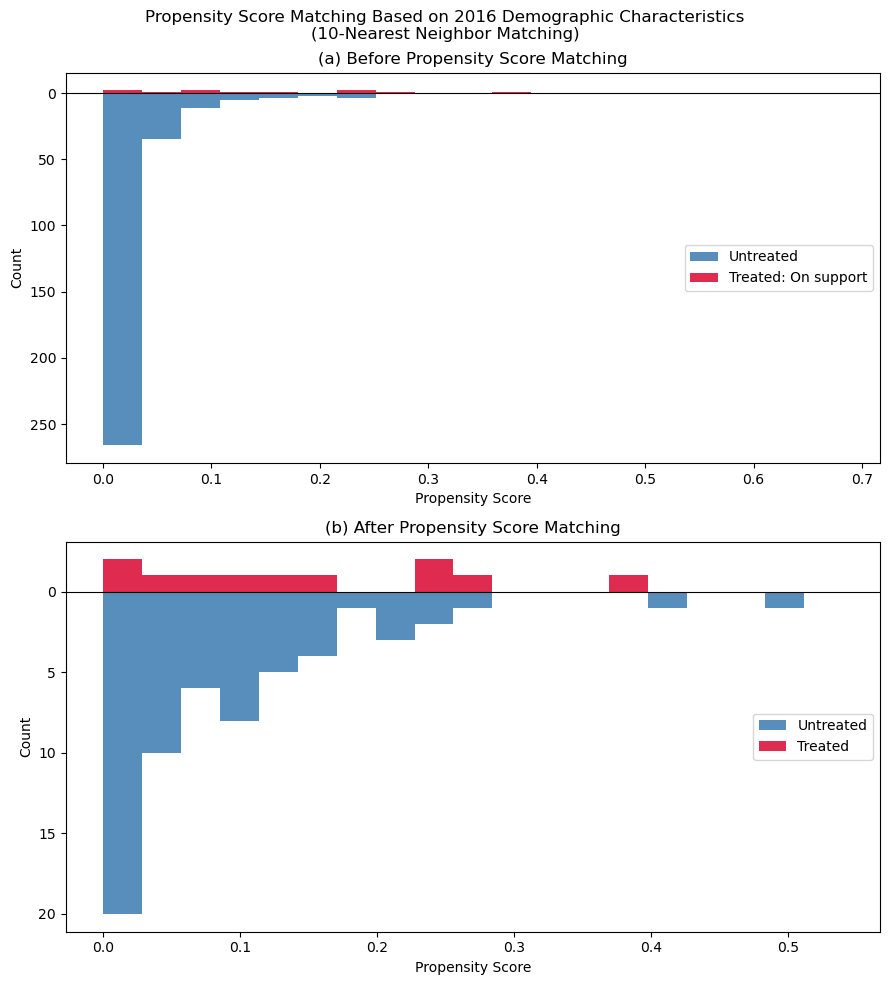

In [43]:
#Plot propensity score distributions before and after matching
fig, axes = plt.subplots(2, 1, figsize=(9, 10))                                                                                                                                        
                                                                                                                                                                                        
bins = np.linspace(0, df["propensity_score"].max() + 0.05, 20)                                                                                                                         
                                                                                                                                                                                        
# --- Panel (a): Before matching ---                                                                                                                                                   
ax = axes[0]    
                                                                                                                                                                                        
untreated_ps = df[df["treated"] == 0]["propensity_score"]
treated_on_ps = treated_in_support["propensity_score"]                                                                                                                                 
treated_off_ps = excluded["propensity_score"]  # outside common support                                                                                                                
                                                                                                                                                                                        
# Untreated bars go downward                                                                                                                                                           
ax.hist(untreated_ps, bins=bins, color="steelblue", alpha=0.9, label="Untreated",                                                                                                      
        weights=np.ones(len(untreated_ps)) * -1)                                                                                                                                       
# Treated on support bars go upward                                                                                                                                                    
ax.hist(treated_on_ps, bins=bins, color="crimson", alpha=0.9, label="Treated: On support")                                                                                             
# Treated off support                                                                                                                                                                  
if len(treated_off_ps) > 0:                                                                                                                                                            
    ax.hist(treated_off_ps, bins=bins, color="mediumseagreen", alpha=0.9, label="Treated: Off support")                                                                                
                                                                                                                                                                                        
ax.axhline(0, color="black", linewidth=0.8)                                                                                                                                            
ax.set_xlabel("Propensity Score")                                                                                                                                                      
ax.set_ylabel("Count")                                                                                                                                                                 
ax.set_title("(a) Before Propensity Score Matching")
ax.legend(loc="right")                                                                                                                                                                 
# Flip y-axis labels to positive
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))                                                                                                         
                                                                                                                                                                                        
# --- Panel (b): After matching ---                                                                                                                                                    
ax = axes[1]                                                                                                                                                                           
                
bins2 = np.linspace(0, max(treated_in_support["propensity_score"].max(),                                                                                                               
                            matched_untreated_unique["propensity_score"].max()) + 0.05, 20)
                                                                                                                                                                                        
control_ps = matched_untreated_unique["propensity_score"]
                                                                                                                                                                                        
ax.hist(control_ps, bins=bins2, color="steelblue", alpha=0.9, label="Untreated",                                                                                                       
        weights=np.ones(len(control_ps)) * -1)
ax.hist(treated_in_support["propensity_score"], bins=bins2, color="crimson", alpha=0.9, label="Treated")                                                                               
                                                                                                                                                                                        
ax.axhline(0, color="black", linewidth=0.8)                                                                                                                                            
ax.set_xlabel("Propensity Score")                                                                                                                                                      
ax.set_ylabel("Count")                                                                                                                                                                 
ax.set_title("(b) After Propensity Score Matching")
ax.legend(loc="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))                                                                                                         

fig.suptitle("Propensity Score Matching Based on 2016 Demographic Characteristics\n(10-Nearest Neighbor Matching)",                                                                    
            fontsize=12)
plt.tight_layout()                                                                                                                                                                     
plt.show() 

In [45]:
#Check average propensity score distance between matched pairs
print("Average propensity score distance between matched pairs:")                                                                                                                        
print(f"Treated mean: {treated_in_support['propensity_score'].mean():.4f}")                                                                                                              
print(f"Control mean: {matched_untreated_unique['propensity_score'].mean():.4f}")  

Average propensity score distance between matched pairs:
Treated mean: 0.1500
Control mean: 0.0940


In [48]:
# Save matched sample
matched_sample = pd.concat([
    treated_in_support.assign(group="treated"),
    matched_untreated_unique.assign(group="control")
], ignore_index=True)

matched_sample.to_csv(matching_dir / "va_matched_tracts.csv", index=False)
print(f"Saved {len(matched_sample):,} rows to va_matched_tracts.csv")
print(f"  Treated: {(matched_sample['group'] == 'treated').sum()}")
print(f"  Control: {(matched_sample['group'] == 'control').sum()}")

Saved 73 rows to va_matched_tracts.csv
  Treated: 11
  Control: 62
